# ⚡ Original strategy: signal-consensus target-risk allocation

## 🧭 tl;dr

This strategy combines fast and slow trend signals with relative momentum and a market-volatility gate. Instead of trusting one moving-average speed, it gives risk-on allocation to assets where signals agree and becomes more selective when the broad market is volatile.

> Educational research only. Not financial advice. This is an original hypothesis built from the library’s trend, momentum, volatility, and crisis research.

<div style="border-left: 5px solid #9333EA; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #FAF5FF; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>The central idea is signal agreement. A fast trend can catch a turn but whipsaw; a slow trend can be steadier but late. Requiring consensus attempts to balance those errors.</div>


## 💡 Research motivation and hypothesis

Earlier notebooks tested fast, medium, slow, and multi-speed Man AHL-style trends, as well as volatility-managed momentum and momentum-crash research. A recent momentum-turning-points paper argues that blending different signal speeds can help around reversals. See [Momentum Turning Points](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3489539).

**Original hypothesis:** when fast and slow trends agree, allocate to the strongest assets; when they disagree, reduce the eligible set; when both are negative during a high-volatility market, move toward defensive ETFs. This is intended to address both false alarms and slow reaction without fitting a large parameter grid.


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_panel():
    tickers = ["SPY", "QQQ", "EFA", "EEM", "TLT", "IEF", "LQD", "GLD", "DBC", "VNQ", "XLE", "XLK", "XLF"]
    try:
        panel = load_price_panel(tickers, "2006-01-01", "2026-01-01")
        source = "Yahoo Finance adjusted daily ETF closes"
    except Exception as exc:
        demo = make_demo_ohlcv(periods=5_000, seed=1304, start="2006-01-01")["close"]
        panel = pd.DataFrame({ticker: demo * (1.0 + 0.015 * i) for i, ticker in enumerate(tickers)}, index=demo.index)
        source = f"deterministic demo ETF panel fallback ({type(exc).__name__})"
    return panel.dropna(), source


close, data_source = load_panel()
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())


Data source: Yahoo Finance adjusted daily ETF closes
Observations: 5,008 | 2006-02-06 to 2025-12-31


,DBC,EEM,EFA,GLD,IEF,LQD,QQQ,SPY,TLT,VNQ,XLE,XLF,XLK
Date,,,,,,,,,,,,,
2006-02-06,19.185099,21.803118,33.987114,56.720001,48.517384,47.331619,34.846813,86.932236,47.462044,27.023010,15.481527,17.145828,8.176646
2006-02-07,18.630157,21.231091,33.735306,54.599998,48.458904,47.212330,34.693119,86.163200,47.237835,26.810505,14.835327,17.032133,8.153526
2006-02-08,18.550879,21.297092,33.855736,54.830002,48.429661,47.212330,35.094444,86.945976,47.128353,26.691502,14.838067,17.140409,8.311515
2006-02-09,18.725288,21.352095,33.921417,56.180000,48.476410,47.287437,34.761444,86.801750,47.342106,26.819008,14.499846,17.183716,8.272975
2006-02-10,18.384398,21.319094,33.844776,54.790001,48.336006,47.199055,34.974915,86.959755,47.081398,26.844503,14.447594,17.281172,8.338487


## 📜 Exact rules

At each month start:

1. Compute 63-day relative momentum, skipping the most recent 21 days.
2. Compute fast and slow trend states: prior close above its 50-day and 200-day SMA.
3. Count consensus: 2 means both trends are positive, 1 means mixed, and 0 means both are negative.
4. Compute broad-market realized volatility from SPY’s trailing 20-day returns.
5. In normal volatility, select the top four assets by momentum among assets with consensus ≥ 1.
6. In high volatility (annualized SPY volatility ≥ 25%), select only assets with consensus = 2.
7. If too few assets qualify, allocate inversely to volatility across TLT, IEF, and GLD.
8. Weight selected assets inversely to 60-day volatility and rebalance monthly.

All indicators are shifted so the decision uses information available before the holding period.


In [3]:

def consensus_speed_weights(close, fast_window=50, slow_window=200, momentum_window=63, skip_recent=21, volatility_window=60, top_n=4, market_vol_threshold=0.25):
    prior = close.shift(1)
    momentum = prior.shift(skip_recent).pct_change(momentum_window)
    fast = prior > prior.rolling(fast_window, min_periods=fast_window).mean()
    slow = prior > prior.rolling(slow_window, min_periods=slow_window).mean()
    consensus = fast.astype(float) + slow.astype(float)
    asset_vol = prior.pct_change().rolling(volatility_window, min_periods=volatility_window).std()
    market_vol = prior["SPY"].pct_change().rolling(20, min_periods=20).std() * np.sqrt(252)
    defensive = [ticker for ticker in ["TLT", "IEF", "GLD"] if ticker in close.columns]

    month = close.index.to_period("M")
    month_start = pd.Series(month, index=close.index).ne(pd.Series(month, index=close.index).shift(1))
    candidates = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    label = pd.Series("uninitialized", index=close.index, dtype="object")
    for timestamp in close.index[month_start.to_numpy()]:
        minimum_consensus = 2.0 if market_vol.loc[timestamp] >= market_vol_threshold else 1.0
        valid = momentum.loc[timestamp].where(consensus.loc[timestamp] >= minimum_consensus).dropna().nlargest(top_n).index
        if len(valid) < top_n:
            selected = pd.Index(defensive)
            label.loc[timestamp] = "defensive fallback"
        else:
            selected = valid
            label.loc[timestamp] = "consensus risk-on"
        risk = asset_vol.loc[timestamp, selected].replace(0.0, np.nan).dropna()
        if len(risk):
            inverse = 1.0 / risk
            candidates.loc[timestamp, inverse.index] = inverse / inverse.sum()

    weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    weights.loc[month_start] = candidates.loc[month_start]
    return weights.ffill().fillna(0.0), label.replace("uninitialized", np.nan).ffill().fillna("warm-up"), consensus, market_vol


def twelve_one_weights(close, top_n=4):
    momentum = close.shift(21).pct_change(252)
    month = close.index.to_period("M")
    month_start = pd.Series(month, index=close.index).ne(pd.Series(month, index=close.index).shift(1))
    candidates = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        valid = momentum.loc[timestamp].dropna()
        if len(valid) >= top_n:
            selected = valid.nlargest(top_n).index
            candidates.loc[timestamp, selected] = 1.0 / top_n
    weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    weights.loc[month_start] = candidates.loc[month_start]
    return weights.ffill().fillna(0.0)


consensus_weights, decision_label, consensus, market_vol = consensus_speed_weights(close)
momentum_weights = twelve_one_weights(close)
consensus_result = run_portfolio_backtest(close, consensus_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
momentum_result = run_portfolio_backtest(close, momentum_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
spy_hold = run_portfolio_backtest(close, pd.DataFrame({"SPY": 1.0, **{ticker: 0.0 for ticker in close.columns if ticker != "SPY"}}, index=close.index), transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
splits = split_time_series(close)
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Results and signal behavior

In [4]:

rows = []
for name, backtest in [("Signal-consensus allocation", consensus_result), ("12–1 momentum", momentum_result), ("SPY buy & hold", spy_hold)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(backtest, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
summary = pd.DataFrame(rows).set_index(["strategy", "period"])
display(summary[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))


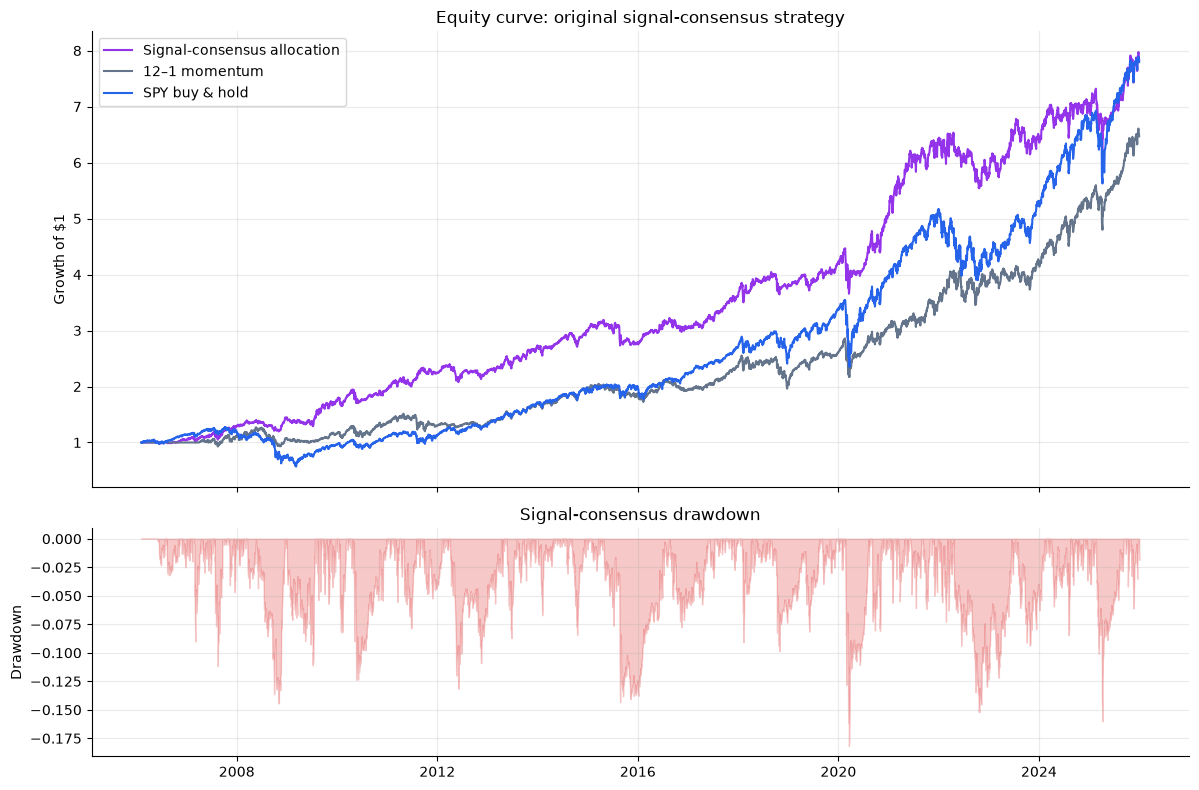

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for backtest, label, color in [(consensus_result, "Signal-consensus allocation", "#9333EA"), (momentum_result, "12–1 momentum", "#64748B"), (spy_hold, "SPY buy & hold", "#2563EB")]:
    axes[0].plot(backtest.frame.index, backtest.frame.equity / backtest.frame.equity.iloc[0], label=label, color=color)
axes[0].set_title("Equity curve: original signal-consensus strategy")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(consensus_result.frame.index, consensus_result.frame.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("Signal-consensus drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


In [6]:

behavior = pd.Series({
    "fraction consensus risk-on": (decision_label == "consensus risk-on").mean(),
    "fraction defensive fallback": (decision_label == "defensive fallback").mean(),
    "fraction high-volatility observations": (market_vol >= 0.25).mean(),
})
display(behavior.to_frame("value").style.format("{:.2%}"))


,value
fraction consensus risk-on,89.60%
fraction defensive fallback,10.40%
fraction high-volatility observations,11.92%


## 🧪 Robustness and stress checks

The base rule uses fast/slow windows of 50/200, a 63-day momentum signal, and a 25% high-volatility threshold. We vary the high-volatility threshold and the number of selected assets, ranking only on validation.


In [7]:

grid_rows = []
for top_n, threshold in itertools.product([3, 4, 5], [0.20, 0.25, 0.30]):
    candidate_weights, _, _, _ = consensus_speed_weights(close, top_n=top_n, market_vol_threshold=threshold)
    candidate = run_portfolio_backtest(close, candidate_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    validation = metrics_for_period(candidate, periods["validation"])
    test = metrics_for_period(candidate, periods["test"])
    grid_rows.append({"top_n": top_n, "market_vol_threshold": threshold, "validation_sharpe": validation["sharpe_ratio"], "validation_return": validation["annualized_return"], "test_sharpe": test["sharpe_ratio"], "test_return": test["annualized_return"], "test_drawdown": test["max_drawdown"]})
sensitivity = pd.DataFrame(grid_rows).sort_values("validation_sharpe", ascending=False)
display(sensitivity.style.format({"market_vol_threshold": "{:.0%}", "validation_sharpe": "{:.2f}", "validation_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_return": "{:.2%}", "test_drawdown": "{:.2%}"}))


,top_n,market_vol_threshold,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
4,4,25%,1.05,14.85%,0.43,5.01%,-16.00%
6,5,20%,1.00,12.29%,0.38,3.91%,-22.79%
7,5,25%,0.97,12.98%,0.37,3.87%,-22.89%
5,4,30%,0.93,13.37%,0.41,4.80%,-16.00%
2,3,30%,0.90,14.07%,0.44,5.62%,-17.60%
1,3,25%,0.89,13.79%,0.48,6.23%,-17.60%
3,4,20%,0.88,11.37%,0.30,3.10%,-20.53%
8,5,30%,0.86,11.57%,0.33,3.32%,-22.89%
0,3,20%,0.66,9.40%,0.41,5.05%,-17.60%


In [8]:

stress_rows = []
for label, (start, end) in {"2008 crisis": ("2008-01-01", "2009-12-31"), "2020 shock": ("2020-02-01", "2020-06-30"), "2022 inflation": ("2022-01-01", "2022-12-31")}.items():
    index = close.loc[start:end].index
    for name, backtest in [("Signal-consensus allocation", consensus_result), ("12–1 momentum", momentum_result), ("SPY buy & hold", spy_hold)]:
        metrics = metrics_for_period(backtest, index)
        stress_rows.append({"window": label, "strategy": name, "return": metrics["total_return_after_costs"], "sharpe": metrics["sharpe_ratio"], "drawdown": metrics["max_drawdown"]})
display(pd.DataFrame(stress_rows).style.format({"return": "{:.2%}", "sharpe": "{:.2f}", "drawdown": "{:.2%}"}))


,window,strategy,return,sharpe,drawdown
0,2008 crisis,Signal-consensus allocation,35.01%,1.00,-14.44%
1,2008 crisis,12–1 momentum,4.14%,0.20,-26.98%
2,2008 crisis,SPY buy & hold,-20.14%,-0.15,-51.87%
3,2020 shock,Signal-consensus allocation,-2.65%,-0.19,-18.17%
4,2020 shock,12–1 momentum,-2.59%,-0.02,-24.08%
5,2020 shock,SPY buy & hold,-3.17%,0.08,-33.72%
6,2022 inflation,Signal-consensus allocation,-8.93%,-0.55,-15.20%
7,2022 inflation,12–1 momentum,11.27%,0.62,-16.15%
8,2022 inflation,SPY buy & hold,-18.18%,-0.71,-24.50%


## ⚖️ What went well / what went wrong

### ✅ What went well

- The strategy makes signal disagreement explicit instead of hiding it inside a single optimized moving-average window.
- High-volatility periods trigger a stricter consensus requirement, which is directly connected to the momentum-crash research.
- The defensive fallback makes the strategy usable when few assets have healthy trends.

### ⚠️ What went wrong or remains uncertain

- Consensus can become a delayed signal: by the time both moving averages agree, part of a rebound may already be gone.
- The 25% volatility threshold and fast/slow windows are still choices that can be overfit.
- Multiple signals based on the same price history are correlated; the ensemble may be less diversified than it appears.
- The ETF universe and monthly execution are simplified relative to institutional multi-asset portfolios.

**Bottom line:** this is a promising research direction because its logic is interpretable, but it earns credibility only if the test-period behavior remains stable under new assets, costs, and future data.
